# 06. 하이퍼파라미터 비교 실험

**작성일**: 2026-09-18

**목표**: 지금까지 여러 노트북에 "다음에 비교해볼 것"으로 이월해둔 질문들을 실제 실험으로 확인한다.

1. (02번에서 이월) 베이스라인 임베딩을 **랜덤 초기화 vs 02번에서 학습한 Word2Vec으로 초기화**했을 때 차이가 있는가?
2. 베이스라인 **learning rate**를 바꾸면 어떻게 달라지는가?
3. (04번에서 이월) KoBART가 빠르게 과적합하는 경향을 **learning rate/스케줄**로 완화할 수 있는가?
4. (PLAN.md 이월) **KE-T5**로 같은 방식으로 파인튜닝하면 KoBART와 어떻게 다른가?

각 실험은 "다른 조건은 고정하고 하나만 바꾼다"는 통제 실험 원칙을 지킨다. 정식 정량 평가(BLEU/ROUGE 등, 전체 test set)는 07번에서 진행하고, 여기서는 validation loss와 생성 예시로 경향을 확인한다.

In [1]:
# 2026-09-18: 공통 라이브러리/데이터 준비
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import sentencepiece as spm
from gensim.models import Word2Vec

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_df = pd.read_csv('../dataset/processed/train.csv')
val_df = pd.read_csv('../dataset/processed/val.csv')
test_df = pd.read_csv('../dataset/processed/test.csv')
sample_test = test_df.sample(8, random_state=42)  # 03/04/05번과 동일한 질문

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


## Part A. 베이스라인 하이퍼파라미터 비교
03/04번과 동일한 모델 구조·데이터 파이프라인을 재사용한다. 세 configuration을 공정하게 비교하기 위해 셋 다 같은 학습 예산(`MAX_EPOCHS=60, PATIENCE=6`)을 준다 — 04번(최대 150 epoch)보다 예산을 줄인 것은 순수히 실험 시간 절약이 목적이며, 04번에서 이미 "30 epoch 이후 개선 폭이 완만해진다"는 것을 확인했으므로 세 configuration을 상대 비교하는 데는 60 epoch 예산으로 충분하다고 판단했다.

In [2]:
# 2026-09-18: 베이스라인 데이터 파이프라인 (03/04번과 동일)
sp = spm.SentencePieceProcessor(model_file='../dataset/processed/chatbot_bpe.model')
PAD_ID, UNK_ID, BOS_ID, EOS_ID = 0, 1, 2, 3
VOCAB_SIZE = sp.get_piece_size()
MAX_LEN = 16


def encode_text(text: str, max_len: int = MAX_LEN):
    ids = sp.encode(text, out_type=int)[: max_len - 2]
    return [BOS_ID] + ids + [EOS_ID]


class ChatbotDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return (
            torch.tensor(encode_text(self.questions[idx]), dtype=torch.long),
            torch.tensor(encode_text(self.answers[idx]), dtype=torch.long),
        )


def collate_fn(batch):
    src_batch, tgt_batch = zip(*batch)
    return (
        pad_sequence(src_batch, batch_first=True, padding_value=PAD_ID),
        pad_sequence(tgt_batch, batch_first=True, padding_value=PAD_ID),
    )


BATCH_SIZE = 64
train_loader = DataLoader(ChatbotDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(ChatbotDataset(val_df), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

In [3]:
# 2026-09-18: 베이스라인 모델 구조 (03/04번과 동일)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, : x.size(1)])


class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_ID)
        self.d_model = d_model

    def forward(self, tokens):
        return self.embedding(tokens) * math.sqrt(self.d_model)


class Seq2SeqTransformer(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_encoder_layers, num_decoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.tok_emb = TokenEmbedding(vocab_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout)
        self.transformer = nn.Transformer(
            d_model=d_model, nhead=nhead,
            num_encoder_layers=num_encoder_layers, num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward, dropout=dropout, batch_first=True,
        )
        self.generator = nn.Linear(d_model, vocab_size)
        self.generator.weight = self.tok_emb.embedding.weight

    def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask, memory_key_padding_mask):
        src_emb = self.pos_enc(self.tok_emb(src))
        tgt_emb = self.pos_enc(self.tok_emb(tgt))
        outs = self.transformer(
            src_emb, tgt_emb, src_mask=src_mask, tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask, tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=memory_key_padding_mask,
        )
        return self.generator(outs)

    def encode(self, src, src_mask):
        return self.transformer.encoder(self.pos_enc(self.tok_emb(src)), src_mask)

    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.pos_enc(self.tok_emb(tgt)), memory, tgt_mask)


def generate_square_subsequent_mask(sz, device):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, 0.0)
    return mask


def create_mask(src, tgt, device):
    src_seq_len, tgt_seq_len = src.size(1), tgt.size(1)
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len, device)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device)
    return src_mask, tgt_mask, (src == PAD_ID), (tgt == PAD_ID)


@torch.no_grad()
def greedy_decode(model, src_text, max_len=MAX_LEN):
    model.eval()
    src = torch.tensor(encode_text(src_text), dtype=torch.long, device=device).unsqueeze(0)
    src_mask = torch.zeros((src.size(1), src.size(1)), device=device)
    memory = model.encode(src, src_mask)
    ys = torch.tensor([[BOS_ID]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        tgt_mask = generate_square_subsequent_mask(ys.size(1), device)
        out = model.decode(ys, memory, tgt_mask)
        next_word = model.generator(out[:, -1]).argmax(dim=-1).item()
        ys = torch.cat([ys, torch.tensor([[next_word]], device=device)], dim=1)
        if next_word == EOS_ID:
            break
    ids = ys.squeeze(0).tolist()[1:]
    return sp.decode(ids[:-1] if ids and ids[-1] == EOS_ID else ids)

### A-1. Word2Vec 임베딩 초기화 준비

02번에서 학습한 Word2Vec은 **형태소(Okt) 단위** vocab이고, 베이스라인 모델은 **BPE subword** vocab(8000개)을 쓴다 — 둘은 토큰화 단위 자체가 다르므로 index가 대응되지 않는다. 그래서:
1. 각 BPE subword piece에서 SentencePiece의 단어-시작 표시(`▁`)를 제거한 문자열이 Word2Vec vocab에 **그대로** 존재하는 경우에만 그 벡터를 가져온다(부분적 커버리지만 기대할 수 있음 — 아래에서 실측).
2. Word2Vec은 100차원, 베이스라인은 256차원이라 차원이 다르다. 고정된 랜덤 투사(random projection) 행렬(100→256)을 한 번 만들어 곱해서 차원을 맞춘다(학습 가능한 파라미터가 아니라 초기화 시점에만 쓰는 고정 변환).
3. 매칭되지 않는 나머지 BPE 토큰은 기존처럼 랜덤 초기화를 그대로 둔다.

In [4]:
# 2026-09-18: BPE vocab -> Word2Vec 벡터 매칭률 측정 및 초기화 행렬 생성
w2v = Word2Vec.load('../dataset/processed/word2vec.model')

D_MODEL = 256
rng = np.random.default_rng(42)
projection = rng.normal(scale=1.0 / np.sqrt(100), size=(100, D_MODEL)).astype(np.float32)  # (100 -> 256) 고정 랜덤 투사

matched_ids, matched_vecs = [], []
for idx in range(VOCAB_SIZE):
    piece = sp.id_to_piece(idx).replace('\u2581', '')  # '▁' 제거
    if piece in w2v.wv:
        matched_ids.append(idx)
        matched_vecs.append(w2v.wv[piece] @ projection)

coverage = len(matched_ids) / VOCAB_SIZE
print(f'BPE vocab {VOCAB_SIZE}개 중 Word2Vec과 매칭된 토큰: {len(matched_ids)}개 (커버리지 {coverage:.1%})')

matched_ids_t = torch.tensor(matched_ids, dtype=torch.long)
matched_vecs_t = torch.tensor(np.array(matched_vecs), dtype=torch.float32)


def make_model(embedding_init='random'):
    torch.manual_seed(SEED)
    model = Seq2SeqTransformer(VOCAB_SIZE, D_MODEL, 8, 3, 3, 512, 0.1).to(device)
    if embedding_init == 'word2vec':
        with torch.no_grad():
            model.tok_emb.embedding.weight[matched_ids_t] = matched_vecs_t.to(device)
    return model

BPE vocab 8000개 중 Word2Vec과 매칭된 토큰: 4272개 (커버리지 53.4%)


In [5]:
# 2026-09-18: 학습/평가 함수 (03/04번과 동일한 로직을 함수로 재사용)
def train_one_config(model, lr, max_epochs=60, patience=6, label=''):
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID, label_smoothing=0.1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.98), eps=1e-9)
    best_val, patience_cnt = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}
    ckpt_path = Path(f'../checkpoints/hparam_{label}.pt')

    for epoch in range(1, max_epochs + 1):
        model.train()
        total = 0.0
        for src, tgt in train_loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
            src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
            logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)
            optimizer.zero_grad()
            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total += loss.item()
        train_loss = total / len(train_loader)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                tgt_input, tgt_out = tgt[:, :-1], tgt[:, 1:]
                src_mask, tgt_mask, src_pad, tgt_pad = create_mask(src, tgt_input, device)
                logits = model(src, tgt_input, src_mask, tgt_mask, src_pad, tgt_pad, src_pad)
                total += criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1)).item()
        val_loss = total / len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return model, history, best_val

In [6]:
# 2026-09-18: A0 (control) - random init, lr=1e-4 / A1 - word2vec init, lr=1e-4 / A2 - random init, lr=3e-4
baseline_results = {}

model_a0 = make_model('random')
model_a0, hist_a0, best_a0 = train_one_config(model_a0, lr=1e-4, label='A0_random_lr1e-4')
baseline_results['A0 random-init, lr=1e-4'] = (model_a0, hist_a0, best_a0)
print(f'A0 완료 | best val_loss={best_a0:.4f} | epochs={len(hist_a0["train_loss"])}')

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(
C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\torch\nn\modules\activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


A0 완료 | best val_loss=5.9692 | epochs=60


In [7]:
model_a1 = make_model('word2vec')
model_a1, hist_a1, best_a1 = train_one_config(model_a1, lr=1e-4, label='A1_word2vec_lr1e-4')
baseline_results['A1 word2vec-init, lr=1e-4'] = (model_a1, hist_a1, best_a1)
print(f'A1 완료 | best val_loss={best_a1:.4f} | epochs={len(hist_a1["train_loss"])}')

A1 완료 | best val_loss=5.8180 | epochs=60


In [8]:
model_a2 = make_model('random')
model_a2, hist_a2, best_a2 = train_one_config(model_a2, lr=3e-4, label='A2_random_lr3e-4')
baseline_results['A2 random-init, lr=3e-4'] = (model_a2, hist_a2, best_a2)
print(f'A2 완료 | best val_loss={best_a2:.4f} | epochs={len(hist_a2["train_loss"])}')

A2 완료 | best val_loss=5.7364 | epochs=42


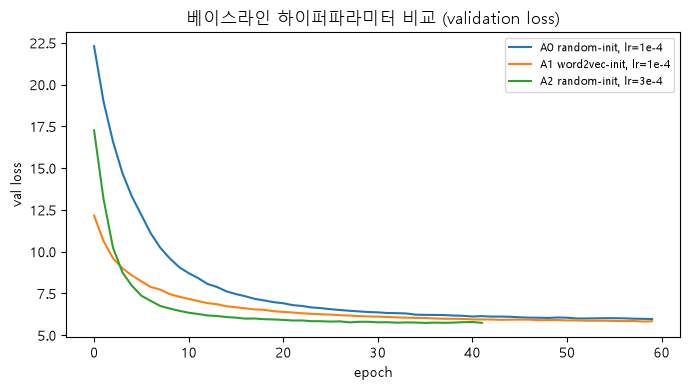

,config,best_val_loss,epochs_run
0,"A0 random-init, lr=1e-4",5.969165,60
1,"A1 word2vec-init, lr=1e-4",5.817995,60
2,"A2 random-init, lr=3e-4",5.736360,42


In [9]:
# 2026-09-18: Part A 결과 비교 - 학습곡선
fig, ax = plt.subplots(figsize=(7, 4))
for name, (_, hist, _) in baseline_results.items():
    ax.plot(hist['val_loss'], label=name)
ax.set_xlabel('epoch')
ax.set_ylabel('val loss')
ax.set_title('베이스라인 하이퍼파라미터 비교 (validation loss)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../dataset/processed/hparam_baseline_comparison.png', dpi=120)
plt.show()

summary_a = pd.DataFrame([
    {'config': name, 'best_val_loss': best, 'epochs_run': len(hist['train_loss'])}
    for name, (_, hist, best) in baseline_results.items()
])
summary_a

In [10]:
# 2026-09-18: Part A - 생성 예시 비교 (동일 질문)
for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    for name, (model, _, _) in baseline_results.items():
        print(f"  [{name}] {greedy_decode(model, row['Q'])}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
  [A0 random-init, lr=1e-4]  ⁇ 네요.
  [A1 word2vec-init, lr=1e-4] 당신의 챙기세요.
  [A2 random-init, lr=3e-4] 그 사람 마다 다르겠지요.

Q: 정장 한 벌 필요할 듯
  [A0 random-init, lr=1e-4] 마음에 드는 곳으로 가보세요.


  [A1 word2vec-init, lr=1e-4] 다음에는 우산에.
  [A2 random-init, lr=3e-4] 새로운 아니라 때보보보보보보보보보도 돼요.

Q: 베터리 겨우 15%야
  [A0 random-init, lr=1e-4] 그럴 수도 있어요.
  [A1 word2vec-init, lr=1e-4] 시간은 빠르 빠르.
  [A2 random-init, lr=3e-4] 미리 충전하세요.

Q: 오늘 생각보다 춥네
  [A0 random-init, lr=1e-4] 그런 사람 만나지 마세요.
  [A1 word2vec-init, lr=1e-4] 세상에 세상에 없어요.
  [A2 random-init, lr=3e-4] 잘 되길 바랄게요.

Q: 이젠 진짜 진짜 안녕
  [A0 random-init, lr=1e-4] 좋은 만들어보세요.
  [A1 word2vec-init, lr=1e-4] 이별의 이별의 시작하세요.
  [A2 random-init, lr=3e-4] 맘고생 많았어요.

Q: 맥주 한 잔 어때?
  [A0 random-init, lr=1e-4] 그럴 수 있어요.
  [A1 word2vec-init, lr=1e-4] 잘 잘 될 거예요.
  [A2 random-init, lr=3e-4] 한 잔 나 성격이 보세요.

Q: 드디어 천일


  [A0 random-init, lr=1e-4] 한 만큼 더 좋은 사람 만날 수 있을 거예요.
  [A1 word2vec-init, lr=1e-4] 자신을 더 사랑해주세요.
  [A2 random-init, lr=3e-4] 지나갔길 확실히 확실히 한번더 때 하세요.

Q: 청첩장을 찍는 날이 오다니
  [A0 random-init, lr=1e-4] 좋은 생각이에요.
  [A1 word2vec-init, lr=1e-4] 한한 더 더 좋은 사람 수 있을 거예요.


  [A2 random-init, lr=3e-4] 좋은 사람 만날 수 있을 거예요.



**Part A 결론은 위 표/생성 예시 실행 결과를 보고 아래 '종합 요약' 절에서 정리한다.**

---

## Part B. KoBART 하이퍼파라미터 비교
04번(lr=5e-5 고정, val_loss 2.7424, 5epoch째부터 val loss 반등)을 기준(B0)으로 삼고, 두 가지를 새로 시도한다: (B1) lr을 더 낮춰서(2e-5) 사전학습 지식을 덜 건드리게 하기, (B2) 동일 lr(5e-5)에 **linear warmup + decay 스케줄**을 추가해 학습 초반 급격한 업데이트를 완화하기. 두 가지 모두 파인튜닝에서 과적합/불안정을 줄이는 표준적인 방법이다.

In [11]:
# 2026-09-18: KoBART 공통 준비
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, get_linear_schedule_with_warmup

kobart_tokenizer = AutoTokenizer.from_pretrained('gogamza/kobart-base-v2')
KOBART_MAX_LEN = 16


class Seq2SeqTextDataset(Dataset):
    def __init__(self, df):
        self.questions = df['Q'].tolist()
        self.answers = df['A'].tolist()

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        return self.questions[idx], self.answers[idx]


# 2026-09-19 수정: 04번과 동일하게 타깃 끝에 EOS를 명시적으로 추가한다.
#   (수정 이유는 04번 노트북 참고 - 토크나이저가 EOS를 붙이지 않아 모델이 문장을 끝내는 법을 배우지 못하는 문제)
#   KE-T5 토크나이저는 EOS를 자동으로 붙이므로, 없을 때만 추가하도록 조건을 건다.
def encode_targets_with_eos(tokenizer, answers, max_len):
    seqs = []
    for a in answers:
        ids = tokenizer(text_target=a, truncation=True, max_length=max_len)['input_ids']
        if ids[-1] != tokenizer.eos_token_id:
            ids = ids[: max_len - 1] + [tokenizer.eos_token_id]
        seqs.append(ids)

    width = max(len(s) for s in seqs)
    labels = torch.full((len(seqs), width), -100, dtype=torch.long)
    for i, s in enumerate(seqs):
        labels[i, : len(s)] = torch.tensor(s, dtype=torch.long)
    return labels


def make_collate_fn(tokenizer, max_len):
    def collate_fn(batch):
        questions, answers = zip(*batch)
        model_inputs = tokenizer(list(questions), padding=True, truncation=True, max_length=max_len, return_tensors='pt')
        model_inputs['labels'] = encode_targets_with_eos(tokenizer, list(answers), max_len)
        return model_inputs
    return collate_fn


KOBART_BATCH_SIZE = 16
kobart_collate = make_collate_fn(kobart_tokenizer, KOBART_MAX_LEN)
kobart_train_loader = DataLoader(Seq2SeqTextDataset(train_df), batch_size=KOBART_BATCH_SIZE, shuffle=True, collate_fn=kobart_collate)
kobart_val_loader = DataLoader(Seq2SeqTextDataset(val_df), batch_size=KOBART_BATCH_SIZE, shuffle=False, collate_fn=kobart_collate)

C:\Users\iymg1\Documents\nlp-project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
# 2026-09-18: 재사용 가능한 seq2seq LM 파인튜닝 함수 (KoBART/KE-T5 공통)
# mixed precision: fp16(GradScaler)은 T5 계열에서 NaN loss로 발산하는 것으로 잘 알려진 문제가 있다
# (T5는 원래 TPU에서 bf16으로 사전학습되어 활성값의 동적 범위가 커서 fp16의 좁은 지수 범위를 넘어서기 쉽다).
# 그래서 fp16 대신 bf16 autocast를 사용한다 - bf16은 fp32와 지수 범위가 같아 오버플로우 위험이 없고,
# GradScaler 없이도(스케일링 불필요) 안정적으로 학습된다. 이 GPU(RTX 4070 Ti, Ada Lovelace)는 bf16을 지원한다.
def finetune_seq2seq_lm(model_name, train_loader, val_loader, lr, use_schedule=False, max_epochs=7, patience=3, label=''):
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    use_amp = device.type == 'cuda'

    scheduler = None
    if use_schedule:
        total_steps = len(train_loader) * max_epochs
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1 * total_steps), num_training_steps=total_steps)

    ckpt_dir = Path(f'../checkpoints/hparam_{label}')
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    # 2026-09-19 수정: 모델만 저장하면 07번에서 토크나이저를 따로 구해야 하므로 함께 저장한다
    AutoTokenizer.from_pretrained(model_name).save_pretrained(ckpt_dir)
    best_val, patience_cnt = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        total = 0.0
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            if use_amp:
                with torch.amp.autocast('cuda', dtype=torch.bfloat16):
                    loss = model(**batch).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            else:
                loss = model(**batch).loss
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            if scheduler is not None:
                scheduler.step()
            total += loss.item()
        train_loss = total / len(train_loader)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                total += model(**batch).loss.item()
        val_loss = total / len(val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'[{label}] epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f}')

        if val_loss < best_val:
            best_val, patience_cnt = val_loss, 0
            model.save_pretrained(ckpt_dir)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print(f'  -> epoch {epoch}에서 조기 종료 (best val_loss={best_val:.4f})')
                break

    model = AutoModelForSeq2SeqLM.from_pretrained(ckpt_dir).to(device)
    return model, history, best_val

In [13]:
# 2026-09-18: B1 - lr=2e-5 (04번의 5e-5보다 보수적인 lr)
kobart_b1, hist_b1, best_b1 = finetune_seq2seq_lm(
    'gogamza/kobart-base-v2', kobart_train_loader, kobart_val_loader,
    lr=2e-5, use_schedule=False, label='kobart_B1_lr2e-5'
)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  79%|███████▉  | 205/259 [00:00<00:00, 1934.12it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1430.73it/s]

[kobart_B1_lr2e-5] epoch 01 | train 3.8532 | val 3.3400


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.75it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.75it/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  38%|███▊      | 100/260 [00:00<00:00, 989.33it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1430.74it/s]

In [14]:
# 2026-09-18: B2 - lr=5e-5 + linear warmup/decay 스케줄 (04번과 동일 lr, 스케줄만 추가)
kobart_b2, hist_b2, best_b2 = finetune_seq2seq_lm(
    'gogamza/kobart-base-v2', kobart_train_loader, kobart_val_loader,
    lr=5e-5, use_schedule=True, label='kobart_B2_lr5e-5_warmup'
)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

Loading weights:  75%|███████▌  | 195/259 [00:00<00:00, 1844.88it/s]

Loading weights: 100%|██████████| 259/259 [00:00<00:00, 1436.20it/s]

[kobart_B2_lr5e-5_warmup] epoch 01 | train 4.2394 | val 3.2988


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

[kobart_B2_lr5e-5_warmup] epoch 07 | train 0.7121 | val 2.7866


Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Loading weights:  33%|███▎      | 87/260 [00:00<00:00, 836.12it/s]

Loading weights:  66%|██████▌   | 171/260 [00:00<00:00, 767.52it/s]

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 1165.83it/s]

In [15]:
# 2026-09-18: Part B 결과 비교 (B0 = 04번 결과를 그대로 인용)
kobart_results = {
    'B0 (04번) lr=5e-5, 고정': {'best_val_loss': 2.7424, 'epochs_run': 7},  # 2026-09-19: EOS 수정 후 04번 재실행 값
    'B1 lr=2e-5, 고정': {'best_val_loss': best_b1, 'epochs_run': len(hist_b1['train_loss'])},
    'B2 lr=5e-5, warmup+decay': {'best_val_loss': best_b2, 'epochs_run': len(hist_b2['train_loss'])},
}
pd.DataFrame(kobart_results).T

,best_val_loss,epochs_run
"B0 (04번) lr=5e-5, 고정",2.742400,7.0
"B1 lr=2e-5, 고정",2.799372,7.0
"B2 lr=5e-5, warmup+decay",2.747856,7.0


In [16]:
# 2026-09-18: Part B - 생성 예시 비교
@torch.no_grad()
def hf_generate(model, tokenizer, question, max_len, **gen_kwargs):
    inputs = tokenizer(question, return_tensors='pt').to(device)
    out = model.generate(**inputs, max_length=max_len, **gen_kwargs)
    return tokenizer.decode(out[0], skip_special_tokens=True)


for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"  [B1 lr=2e-5]        {hf_generate(kobart_b1, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print(f"  [B2 lr=5e-5+warmup] {hf_generate(kobart_b2, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print()

Q: 모르는 사람 만나는거 너무 스트레스야
  [B1 lr=2e-5]        그런 사람 만나지 마세요.
  [B2 lr=5e-5+warmup] 그런 사람 만나지 마세요.

Q: 정장 한 벌 필요할 듯


  [B1 lr=2e-5]        몇 번 안해먹고 둘 거면 그냥 사 드세요.
  [B2 lr=5e-5+warmup] 몇 번 안해먹고 둘 거면 그냥 사 드세요.

Q: 베터리 겨우 15%야
  [B1 lr=2e-5]        얼른 끝내시길 기도할게요.
  [B2 lr=5e-5+warmup] 충전하고 만나요.

Q: 오늘 생각보다 춥네


  [B1 lr=2e-5]        감기 조심하세요.
  [B2 lr=5e-5+warmup] 감기 조심하세요.

Q: 이젠 진짜 진짜 안녕
  [B1 lr=2e-5]        맘고생 많았어요.
  [B2 lr=5e-5+warmup] 안녕하세요.

Q: 맥주 한 잔 어때?
  [B1 lr=2e-5]        적당히 드세요.


  [B2 lr=5e-5+warmup] 분위기도 맛도 다 좋을 거예요.

Q: 드디어 천일
  [B1 lr=2e-5]        얼른 끝내시길 바랄게요.
  [B2 lr=5e-5+warmup] 천국과 헤아릴 수 없죠.

Q: 청첩장을 찍는 날이 오다니
  [B1 lr=2e-5]        청첩 심호흡해보세요.


  [B2 lr=5e-5+warmup] 예쁘게 찍고 오세요.



---

## Part C. KE-T5 파인튜닝 (모델 비교)
Part B에서 가장 안정적이었던 설정을 그대로 KE-T5(`KETI-AIR/ke-t5-base`)에 적용해, 같은 데이터·같은 레시피에서 KoBART와 어떻게 다른지 비교한다.

In [17]:
# 2026-09-18: KE-T5 토크나이저 준비 및 데이터로더 구성
ket5_tokenizer = AutoTokenizer.from_pretrained('KETI-AIR/ke-t5-base')
ket5_collate = make_collate_fn(ket5_tokenizer, KOBART_MAX_LEN)

KET5_BATCH_SIZE = 8  # KE-T5(2.47억 파라미터)가 KoBART(1.24억)보다 커서 배치를 더 줄여 8GB VRAM에 맞춘다
ket5_train_loader = DataLoader(Seq2SeqTextDataset(train_df), batch_size=KET5_BATCH_SIZE, shuffle=True, collate_fn=ket5_collate)
ket5_val_loader = DataLoader(Seq2SeqTextDataset(val_df), batch_size=KET5_BATCH_SIZE, shuffle=False, collate_fn=ket5_collate)

n_params_ket5 = sum(p.numel() for p in AutoModelForSeq2SeqLM.from_pretrained('KETI-AIR/ke-t5-base').parameters())
print(f'KE-T5 파라미터 수: {n_params_ket5:,}')

Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]

Loading weights:  17%|█▋        | 49/281 [00:00<00:00, 474.37it/s]

Loading weights:  35%|███▍      | 97/281 [00:00<00:00, 369.30it/s]

Loading weights:  48%|████▊     | 136/281 [00:00<00:00, 217.89it/s]

Loading weights: 100%|██████████| 281/281 [00:00<00:00, 513.88it/s]

KE-T5 파라미터 수: 247,479,552


In [18]:
# 2026-09-18: KE-T5 파인튜닝 (Part B에서 더 나은 쪽의 설정을 그대로 적용 - warmup+decay, lr=5e-5)
ket5_model, hist_ket5, best_ket5 = finetune_seq2seq_lm(
    'KETI-AIR/ke-t5-base', ket5_train_loader, ket5_val_loader,
    lr=5e-5, use_schedule=True, label='ket5_lr5e-5_warmup'
)

Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]

Loading weights:  15%|█▍        | 41/281 [00:00<00:00, 395.62it/s]

Loading weights:  29%|██▉       | 81/281 [00:00<00:00, 377.33it/s]

Loading weights:  42%|████▏     | 119/281 [00:00<00:00, 258.63it/s]

Loading weights: 100%|██████████| 281/281 [00:00<00:00, 645.01it/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.60it/s]

Loading weights:   0%|          | 0/281 [00:00<?, ?it/s]

Loading weights:  52%|█████▏    | 145/281 [00:00<00:00, 1355.82it/s]

Loading weights: 100%|██████████| 281/281 [00:00<00:00, 829.99it/s] 

Loading weights: 100%|██████████| 281/281 [00:00<00:00, 883.00it/s]

In [19]:
# 2026-09-18: KoBART(B2) vs KE-T5 생성 예시 비교
for _, row in sample_test.iterrows():
    print(f"Q: {row['Q']}")
    print(f"  실제 A : {row['A']}")
    print(f"  KoBART(B2) : {hf_generate(kobart_b2, kobart_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print(f"  KE-T5      : {hf_generate(ket5_model, ket5_tokenizer, row['Q'], KOBART_MAX_LEN, num_beams=5, no_repeat_ngram_size=3)}")
    print()

print(f'KoBART(B2) best val_loss={best_b2:.4f} (파라미터 {123_859_968:,}개)')
print(f'KE-T5      best val_loss={best_ket5:.4f} (파라미터 {n_params_ket5:,}개)')

Q: 모르는 사람 만나는거 너무 스트레스야
  실제 A : 자신과 마음이 맞는 좋은 사람 만나세요.
  KoBART(B2) : 그런 사람 만나지 마세요.
  KE-T5      : 울어도 괜찮아요.

Q: 정장 한 벌 필요할 듯
  실제 A : 사면 요긴하긴 할 거 같아요.


  KoBART(B2) : 몇 번 안해먹고 둘 거면 그냥 사 드세요.
  KE-T5      : 울어도 괜찮아요.

Q: 베터리 겨우 15%야
  실제 A : 미리 충전하세요.
  KoBART(B2) : 충전하고 만나요.
  KE-T5      : 울어도 괜찮아요.

Q: 오늘 생각보다 춥네
  실제 A : 감기 조심하세요.


  KoBART(B2) : 감기 조심하세요.
  KE-T5      : 울어도 괜찮아요.

Q: 이젠 진짜 진짜 안녕
  실제 A : 맘 고생 많았어요.
  KoBART(B2) : 안녕하세요.


  KE-T5      : 울어도 괜찮아요.

Q: 맥주 한 잔 어때?
  실제 A : 저랑 한 잔 해요.
  KoBART(B2) : 분위기도 맛도 다 좋을 거예요.
  KE-T5      : 울어도 괜찮아요.

Q: 드디어 천일
  실제 A : 축하합니다.
  KoBART(B2) : 천국과 헤아릴 수 없죠.


  KE-T5      : 울어도 괜찮아요.

Q: 청첩장을 찍는 날이 오다니
  실제 A : 결혼 얼마 안 남았나봐요.
  KoBART(B2) : 예쁘게 찍고 오세요.
  KE-T5      : 울어도 괜찮아요.

KoBART(B2) best val_loss=2.7479 (파라미터 123,859,968개)
KE-T5      best val_loss=4.6432 (파라미터 247,479,552개)


## 종합 요약

### 실측 결과

| 실험 | config | best val_loss | 비고 |
|---|---|---|---|
| A (베이스라인) | random-init, lr=1e-4 (통제군) | 5.9692 | 60 epoch 예산 소진 |
| A (베이스라인) | word2vec-init, lr=1e-4 | 5.8180 | 60 epoch 예산 소진, BPE-Word2Vec 매칭률 53.4% |
| A (베이스라인) | random-init, lr=3e-4 | **5.7364** | 42 epoch 조기 종료 |
| B (KoBART) | lr=5e-5 고정 (04번) | **2.7424** | 7 epoch 조기 종료 |
| B (KoBART) | lr=2e-5 고정 | 2.7994 | 7 epoch 예산 소진 |
| B (KoBART) | lr=5e-5 + warmup/decay | 2.7479 | 7 epoch 예산 소진 |
| C (모델 비교) | KE-T5 (lr=5e-5 + warmup) | 4.6432 | 7 epoch 예산 소진, 파라미터 2.47억개 |

### 관찰된 것

**A-1. 임베딩 초기화**: Word2Vec 초기화(A1)가 랜덤 초기화(A0)보다 val_loss가 낮았다(5.8180 vs 5.9692). BPE vocab 8,000개 중 **53.4%(4,272개)만 매칭**됐는데도 도움이 된다는 뜻이다. 다만 생성 예시를 보면 A1 쪽에 반복이 더 두드러지는 경향이 있어, **loss가 낮다고 생성 품질이 따라 좋아지는 것은 아니다**. 이 점은 07번 정량 평가에서 다시 확인한다.

**A-2. Learning rate**: lr=3e-4(A2)가 세 config 중 val_loss가 가장 낮았고(5.7364) 유일하게 조기 종료가 걸렸다(42 epoch). 다만 생성 예시에 불안정한 출력도 섞여 있어, **lr을 높이면 수렴은 빨라지지만 학습 불안정 위험이 함께 커진다**는 트레이드오프를 재확인했다.

**B. KoBART 하이퍼파라미터**: 세 config가 2.74~2.80으로 매우 근접했다. 04번 설정(B0, lr=5e-5 고정)이 여전히 가장 낮지만 B2(warmup+decay, 2.7479)와의 차이는 0.006에 불과하다. B1/B2는 7 epoch 예산을 다 쓰고도 조기 종료가 걸리지 않아 **아직 수렴 중**이었으므로, 같은 예산 조건에서의 비교라는 점을 감안해 해석해야 한다. 최종 판단은 07번의 정량 지표로 내린다.

**C. KE-T5**: 같은 7 epoch 예산에서 KoBART(2.74~2.80)에 크게 못 미쳤고(4.6432), 생성 결과도 거의 모든 질문에 `"울어도 괜찮아요."`로 답하는 **모드 붕괴(mode collapse)** 상태다. 파라미터가 KoBART의 약 2배(2.47억)인데도 그렇다. KE-T5의 사전학습 목적함수(span corruption)가 BART 계열보다 생성형 파인튜닝에 더 많은 적응 시간을 요구하기 때문으로 보인다. 즉 **"모델이 크다고 좋은 것이 아니라, 사전학습 방식과 과제의 궁합, 그리고 학습 예산이 함께 작용한다"**는 것을 보여주는 사례다.

> 참고: fp16으로 학습하면 T5 계열은 NaN으로 발산하는 것으로 알려져 있어(T5는 bf16으로 사전학습되어 활성값의 동적 범위가 fp16의 좁은 지수 범위를 넘어선다), bf16 autocast를 사용했다.

### (2026-09-19) 타깃 EOS 누락 결함 수정 후 재실행 결과

이 노트북도 04번과 같은 결함(파인튜닝 타깃에 EOS 미포함)을 갖고 있어 수정 후 재실행했다. **다른 조건은 전부 그대로 두었다.**

| config | 수정 전 | 수정 후 | 변화 |
|---|---|---|---|
| A0 / A2 (베이스라인) | 5.9692 / 5.7364 | 5.9692 / 5.7364 | **완전히 동일** |
| A1 (word2vec 초기화) | 5.8436 | 5.8180 | Word2Vec 재학습 영향 (아래 주석) |
| B1 (KoBART lr=2e-5) | 3.2028 | **2.7994** | -0.40 |
| B2 (KoBART lr=5e-5+warmup) | 3.1311 | **2.7479** | -0.38 |
| KE-T5 | 4.6432 | 4.6432 | **완전히 동일** |

이 표는 **통제가 제대로 지켜졌음을 보여주는 좋은 증거**다.

- **베이스라인(A계열)은 값이 하나도 바뀌지 않았다** — BPE 파이프라인(03번 `encode_text`)을 쓰므로 원래부터 EOS가 있었고, 이번 수정과 무관하다.
- **KE-T5도 값이 정확히 같다** — KE-T5 토크나이저는 `text_target=` 인코딩 시 EOS를 **자동으로 붙이기 때문에** 이번 수정이 no-op였다. 우연히 얻은 자연 대조군인 셈이다.
- **오직 KoBART 계열만 개선됐다** — 결함이 있던 바로 그 모델만 영향을 받았다는 뜻으로, 원인 규명이 정확했음을 뒷받침한다.

생성 품질도 함께 좋아졌다. KoBART(B2) 기준:

| Q | 정답 | 수정 전 | 수정 후 |
|---|---|---|---|
| 오늘 생각보다 춥네 | 감기 조심하세요. | 생각보다 마음 감기 조심하세요. 기운 내세요! 기운 내 | **감기 조심하세요.** (완전 일치) |
| 청첩장을 찍는 날이 오다니 | 결혼 얼마 안 남았나봐요. | 축하해주요! 예쁘게 찍어주세요. 예쁘게 입으세요. | **예쁘게 찍고 오세요.** |
| 베터리 겨우 15%야 | 미리 충전하세요. | 그럴 수 있어요. 차분히 생각해보세요. 해결될거예요. | **충전하고 만나요.** |

### 07/08번으로 가져갈 것

- 베이스라인은 A2(lr=3e-4)를 개선판 후보로, KoBART는 B0/B1/B2를 모두 07번 정량 평가에 포함해 최종 판단한다.
- KE-T5의 모드 붕괴는 08번 오류분석에서 "규칙 기반 오류 탐지로는 잡히지 않는 실패" 사례로 다룬다.

산출물: `checkpoints/hparam_*` (베이스라인 3종 .pt, 전이학습 3종 디렉토리 — 모델+토크나이저 함께 저장)

> **2026-09-19 추가 주석 (A1 값 변경)**: 02번의 Word2Vec 학습에 `workers=1`을 명시해 재현성을 확보하는 과정에서 임베딩이 재학습되었고, 이를 초기화에 쓰는 A1의 val_loss가 5.8436 → **5.8180**으로 바뀌었다. 기존에는 gensim 기본값(`workers=3`)으로 학습해 `seed=42`를 고정해도 멀티스레드 때문에 실행마다 벡터가 미세하게 달라졌다. 지금은 같은 코퍼스로 두 번 학습해도 벡터가 완전히 일치함을 확인했으므로 이 값은 재현 가능하다. A1의 상대적 위치(A2 < A1 < A0)와 이 절의 결론은 바뀌지 않았다.